[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1pOs_uSvwNLOBRsNZHvgYVcWKrvemf3yB)

# Data

We'll be using the newly released dataset to model authorship of Victorian Era literature.

http://archive.ics.uci.edu/ml/datasets/Victorian+Era+Authorship+Attribution

We will use this dataset to classify authors based on their writings.

Download links available at – https://dataworks.iupui.edu/handle/11243/23

In [1]:
import pandas as pd

df = pd.read_csv('https://dataworks.iupui.edu/bitstream/handle/11243/23/Gungor_2018_VictorianAuthorAttribution_data-train.csv?sequence=2&isAllowed=y', encoding='ISO-8859-1')
df.head()

,text,author
0,ou have time to listen i will give you the ent...,1
1,wish for solitude he was twenty years of age a...,1
2,and the skirt blew in perfect freedom about th...,1
3,of san and the rows of shops opposite impresse...,1
4,an hour s walk was as tiresome as three in a s...,1


In [0]:
seed = 42

In [3]:
df.shape

(53678, 2)

Dataset is huge – Let's sample a subset for iterating (once we finalize our model, we can run the model on the entire dataset)

In [30]:
data = df.sample(frac=0.1)
data.shape

(5368, 2)

# TensorFlow Hub

"A library for reusable machine learning modules"

> This lets you quickly take advantage of a model that was trained with thousands of GPU hours. It also enables transfer learning - reusing a part of a trained model (called a module) that includes weights and assets, but also training the overall model some yourself with your own data. The advantages are fairly clear - you can use less training data, have faster training, and have a model that generalizes better.

https://www.tensorflow.org/hub/

In [31]:
texts = data['text'].tolist()
texts[0:5]

['shall get up and dress me and wind that pretty wreath of yours which sure you will lend me around my head and meet just at the tree at uie end of the garden then as to the return you you told mother you could not go to me ng because you was going to with old and i heard tke doctor say be did not believe she would live the night through this is clear luck what mother would call at any rate jou know if she should not be any worse you can sit op till o clock and i will just tap at ed room window and you won t refuse jane to slip the of the outside door for me jane told her she could not take part in her projects but trusting to the impulse of her s good nature to her plan mrs was not on this occasion so keen as usual she had that very day received proposals of marriage from a broken merchant and though â be had no idea of her estates and liberty she was a g o deal fluttered with what she would fain have believed to be a compliment to her personal charms every thing succeeded to s most s

### Use pre-trained embeddings, trained on English Google News 200B corpus

https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1

In [7]:
import tensorflow as tf
import tensorflow_hub as hub

with tf.Graph().as_default():
  module_url = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1"
  embed = hub.Module(module_url)
  embeddings = embed(texts)

  with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    sess.run(tf.tables_initializer())

    print(sess.run(embeddings))
    X = embeddings.eval()

INFO:tensorflow:Using /tmp/tfhub_modules to cache modules.
INFO:tensorflow:Downloading TF-Hub Module 'https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1'.
INFO:tensorflow:Downloaded TF-Hub Module 'https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1'.
INFO:tensorflow:Saver not created because there are no variables in the graph to restore
[[ 4.4734154   0.10362072  0.923081   ... -1.0131123  -0.18775244
  -0.01076623]
 [ 4.696453   -0.2467599   0.40367854 ... -1.332848    0.6095339
  -0.2023697 ]
 [ 4.654124    0.06876806  0.56487966 ... -0.85070467  0.11801764
  -0.09897577]
 ...
 [ 4.487185    0.41545427  0.47470132 ... -0.9591097  -0.19196934
   0.26032454]
 [ 4.0576506   0.13050397  0.25490206 ... -1.4366132   0.02078641
  -0.36060297]
 [ 4.456136    0.16633408  0.69851285 ... -0.6068457  -0.13067153
   0.11404806]]


In [8]:
X.shape

(5368, 128)

In [9]:
embedding_dimensions = X.shape[1]
print('Dimension of Embeddings:', embedding_dimensions)

Dimension of Embeddings: 128


# Baseline Model

In [10]:
authors = data['author'].tolist()
print(authors)

[33, 48, 48, 22, 21, 45, 10, 37, 36, 26, 26, 8, 1, 9, 33, 21, 9, 36, 41, 50, 15, 8, 37, 50, 15, 50, 15, 32, 36, 8, 26, 14, 14, 14, 8, 26, 39, 14, 6, 30, 9, 14, 21, 26, 30, 8, 25, 33, 21, 50, 8, 19, 12, 35, 37, 8, 21, 10, 4, 8, 14, 45, 19, 4, 21, 8, 29, 37, 14, 13, 8, 8, 38, 9, 38, 8, 37, 8, 46, 28, 37, 40, 33, 50, 30, 46, 39, 41, 9, 36, 30, 26, 45, 39, 8, 23, 8, 22, 21, 18, 22, 8, 26, 14, 9, 14, 4, 23, 48, 8, 46, 37, 39, 37, 45, 8, 28, 36, 19, 45, 1, 39, 8, 44, 46, 8, 12, 10, 46, 30, 25, 21, 15, 39, 45, 48, 14, 37, 18, 33, 21, 39, 35, 43, 14, 20, 32, 43, 1, 39, 26, 24, 43, 23, 42, 18, 21, 21, 18, 37, 17, 8, 8, 43, 42, 4, 11, 28, 38, 4, 45, 41, 8, 26, 2, 28, 33, 8, 25, 32, 14, 48, 8, 37, 48, 17, 8, 18, 15, 37, 43, 44, 15, 8, 35, 37, 40, 18, 8, 8, 37, 8, 36, 8, 26, 17, 36, 48, 33, 21, 19, 18, 4, 17, 4, 17, 39, 25, 37, 4, 32, 50, 14, 26, 8, 33, 4, 8, 14, 10, 14, 35, 24, 30, 35, 43, 26, 8, 14, 8, 32, 8, 19, 41, 21, 25, 10, 30, 36, 41, 37, 33, 9, 10, 33, 15, 1, 15, 12, 18, 45, 17, 13, 14, 2

In [11]:
num_classes = max(authors) + 1
print('Number of unique labels:', num_classes)

Number of unique labels: 51


Make "one-hot" encodings from labels

In [12]:
from keras.utils import to_categorical

y = to_categorical(authors, num_classes)
print(y.shape)
y

(5368, 51)


Using TensorFlow backend.


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [0]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [14]:
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (4294, 128) (4294, 51)
Test: (1074, 128) (1074, 51)


In [19]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(embedding_dimensions, input_dim=embedding_dimensions, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_5 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_6 (Dense)              (None, 51)                6579      
Total params: 23,091
Trainable params: 23,091
Non-trainable params: 0
_________________________________________________________________
None


In [20]:
fitted_model = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=32, verbose=2)

Train on 4294 samples, validate on 1074 samples
Epoch 1/10
 - 0s - loss: 3.2453 - acc: 0.2059 - val_loss: 2.9183 - val_acc: 0.2737
Epoch 2/10
 - 0s - loss: 2.7472 - acc: 0.2944 - val_loss: 2.5803 - val_acc: 0.3408
Epoch 3/10
 - 0s - loss: 2.4495 - acc: 0.3589 - val_loss: 2.3549 - val_acc: 0.3585
Epoch 4/10
 - 0s - loss: 2.2434 - acc: 0.4029 - val_loss: 2.1815 - val_acc: 0.4330
Epoch 5/10
 - 0s - loss: 2.0673 - acc: 0.4590 - val_loss: 2.0370 - val_acc: 0.4777
Epoch 6/10
 - 0s - loss: 1.9342 - acc: 0.4863 - val_loss: 1.9470 - val_acc: 0.5093
Epoch 7/10
 - 0s - loss: 1.8053 - acc: 0.5272 - val_loss: 1.8529 - val_acc: 0.5056
Epoch 8/10
 - 0s - loss: 1.7036 - acc: 0.5552 - val_loss: 1.7683 - val_acc: 0.5279
Epoch 9/10
 - 0s - loss: 1.6273 - acc: 0.5708 - val_loss: 1.6709 - val_acc: 0.5745
Epoch 10/10
 - 0s - loss: 1.5384 - acc: 0.5932 - val_loss: 1.6384 - val_acc: 0.5912


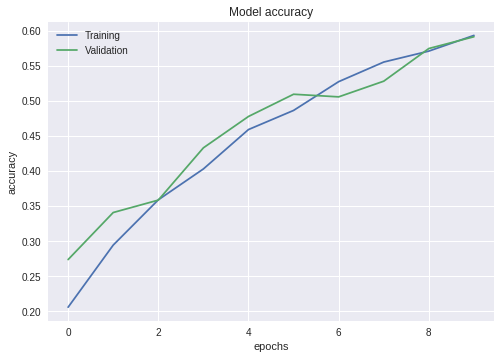

In [21]:
import matplotlib.pyplot as plt

plt.plot(fitted_model.history['acc'], label="Training")
plt.plot(fitted_model.history['val_acc'], label="Validation")
plt.title("Model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show();

**Observation:** Both the training and the validation accuracy seems to be increasing with more epochs => hints we should probably try a higher number of epochs

# Hyperparameter Tuning

using GridSearchCV

In [0]:
from keras.layers import Dropout

def create_model(num_neurons, dropout):
  model = Sequential()
  model.add(Dense(num_neurons, input_dim=embedding_dimensions, activation='relu'))
  if dropout > 0.0:
    model.add(Dropout(dropout))  
  model.add(Dense(num_classes, activation='softmax'))
  
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])  
  return model

In [24]:
batch_size = [32]
epochs = [5, 10, 50, 100]
num_neurons = [embedding_dimensions, embedding_dimensions*2, embedding_dimensions*4]
dropout = [0.0, 0.5]

hyperparam_grid = dict(batch_size=batch_size, 
                       epochs=epochs, 
                       num_neurons=num_neurons, 
                       dropout=dropout)

hyperparam_grid

{'batch_size': [32],
 'dropout': [0.0, 0.5],
 'epochs': [5, 10, 50, 100],
 'num_neurons': [128, 256, 512]}

In [0]:
from keras.wrappers.scikit_learn import KerasClassifier

estimator = KerasClassifier(build_fn=create_model, verbose=2)

In [0]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=estimator, param_grid=hyperparam_grid, cv=3, verbose=2)
grid_result = grid_search.fit(x_train, y_train)

In [27]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

for mean, std, param in zip(means, stds, params):
  print("%f (%f) with: %r" % (mean, std, param))

Best: 0.717513 using {'batch_size': 32, 'dropout': 0.0, 'epochs': 100, 'num_neurons': 512}
0.388449 (0.032945) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 5, 'num_neurons': 128}
0.438286 (0.028216) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 5, 'num_neurons': 256}
0.470890 (0.030828) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 5, 'num_neurons': 512}
0.499767 (0.018168) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 10, 'num_neurons': 128}
0.556125 (0.011826) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 10, 'num_neurons': 256}
0.594318 (0.002565) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 10, 'num_neurons': 512}
0.667210 (0.023119) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 50, 'num_neurons': 128}
0.687238 (0.009612) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 50, 'num_neurons': 256}
0.699814 (0.009615) with: {'batch_size': 32, 'dropout': 0.0, 'epochs': 50, 'num_neurons': 512}
0.698882 (0.011370) with: {'batch_size': 32, 'dropout': 0

**Best: 0.717513 using {'batch_size': 32, 'dropout': 0.0, 'epochs': 100, 'num_neurons': 512}**

# Final model

Let's discard the sample set and use the entire set now

In [32]:
data = df.copy()
data.shape

(53678, 2)

In [33]:
texts = data['text'].tolist()
texts[0:5]

['ou have time to listen i will give you the entire story he said it may form the basis of a future novel and prove quite as interesting as one of your own invention i had the time to listen of course one has time for anything and everything agreeable in the best place to hear the tale was in a victoria and with my good on the box with the coachman we set out at once on a drive to the as the recital was only half through when we reached the house we postponed the remainder while we stopped there for an excellent lunch on the way back to my friend continued and finished the story it was indeed quite suitable for use and i told my friend with thanks that i should at once put it in shape for my readers i said i should make a few alterations in it for the sake of dramatic interest but in the main would follow the lines he had given me it would spoil my romance were i to answer on this page the question that must be uppermost in the reader s mind i have already revealed almost too much of t

In [34]:
with tf.Graph().as_default():
  module_url = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/1"
  embed = hub.Module(module_url)
  embeddings = embed(texts)

  with tf.Session() as sess:
    sess.run(tf.global_variables_initializer())
    sess.run(tf.tables_initializer())

    print(sess.run(embeddings))
    X = embeddings.eval()

INFO:tensorflow:Saver not created because there are no variables in the graph to restore
[[ 4.742724   -0.03984392  0.4347267  ... -1.381325    0.4436839
   0.3926557 ]
 [ 4.638058    0.11435992  0.5076428  ... -1.3490543   0.14249295
   0.08708809]
 [ 4.657072    0.05044416  0.31282306 ... -1.3132746  -0.16678776
  -0.00755485]
 ...
 [ 4.2718134  -0.01576476  0.70100456 ... -0.91154325 -0.24903299
   0.06295525]
 [ 4.3038507  -0.05889306  0.7539825  ... -0.9108152  -0.09493008
  -0.0821903 ]
 [ 4.27195    -0.13434537  0.54746425 ... -0.95999247 -0.05214985
   0.01255544]]


In [35]:
X.shape

(53678, 128)

In [36]:
embedding_dimensions = X.shape[1]
print('Dimension of Embeddings:', embedding_dimensions)

Dimension of Embeddings: 128


In [0]:
authors = data['author'].tolist()

In [39]:
num_classes = max(authors) + 1
print('Number of unique labels:', num_classes)
y = to_categorical(authors, num_classes)
print(y.shape)

Number of unique labels: 51
(53678, 51)


In [0]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [41]:
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (42942, 128) (42942, 51)
Test: (10736, 128) (10736, 51)


In [42]:
model = Sequential()
model.add(Dense(512, input_dim=embedding_dimensions, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
fitted_model = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=32, verbose=2)

Train on 42942 samples, validate on 10736 samples
Epoch 1/100
 - 11s - loss: 1.8663 - acc: 0.5101 - val_loss: 1.3102 - val_acc: 0.6614
Epoch 2/100
 - 6s - loss: 1.1501 - acc: 0.6863 - val_loss: 1.0074 - val_acc: 0.7269
Epoch 3/100
 - 6s - loss: 0.9350 - acc: 0.7408 - val_loss: 0.8817 - val_acc: 0.7586
Epoch 4/100
 - 6s - loss: 0.8147 - acc: 0.7724 - val_loss: 0.8413 - val_acc: 0.7654
Epoch 5/100
 - 6s - loss: 0.7377 - acc: 0.7916 - val_loss: 0.7737 - val_acc: 0.7854
Epoch 6/100
 - 6s - loss: 0.6752 - acc: 0.8092 - val_loss: 0.6965 - val_acc: 0.8044
Epoch 7/100
 - 6s - loss: 0.6302 - acc: 0.8204 - val_loss: 0.6720 - val_acc: 0.8145
Epoch 8/100
 - 6s - loss: 0.5944 - acc: 0.8288 - val_loss: 0.6531 - val_acc: 0.8183
Epoch 9/100
 - 6s - loss: 0.5589 - acc: 0.8378 - val_loss: 0.6134 - val_acc: 0.8307
Epoch 10/100
 - 6s - loss: 0.5313 - acc: 0.8484 - val_loss: 0.6417 - val_acc: 0.8259
Epoch 11/100
 - 5s - loss: 0.5058 - acc: 0.8539 - val_loss: 0.5969 - val_acc: 0.8373
Epoch 12/100
 - 6s - lo

Let's confirm the accuracy on the Test set we had

In [43]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print('Accuracy: %.2f%%' % (accuracy * 100))

Accuracy: 86.91%


**Summary**

Best accuracy score was 86.91%, achieved by a Dense layer of 512 neurons with no Dropout, with epochs=100  and batch_size=32